In [ ]:
# Ensure correct column names for this dataset (many datasets use `file_name` and `ground`)
if {'file_name','ground'}.issubset(set(train_df.columns)):
    img_column = 'file_name'
    id_column = 'ground'
else:
    # fallback to previous automatic detection
    id_column = [c for c in train_df.columns if c.lower() in ['id', 'jaguar_id', 'identity', 'class']][0] if any(c.lower() in ['id', 'jaguar_id', 'identity', 'class'] for c in train_df.columns) else train_df.columns[1]
    img_column = [c for c in train_df.columns if c.lower() in ['image', 'image_id', 'filename', 'image_path', 'file_name']][0] if any(c.lower() in ['image', 'image_id', 'filename', 'image_path', 'file_name'] for c in train_df.columns) else train_df.columns[0]

print(f"Using image column: {img_column}, id column: {id_column}")

# Step 2 — Preprocessing & Data Setup

Objectives:
- Define augmentations and preprocessing transforms
- Create group-aware train/validation split (by jaguar identity)
- Implement a PyTorch `Dataset` skeleton and example `DataLoader`s
- Visualize augmented samples and save the splits for reproducibility

Run the cell below to perform these steps and inspect outputs.

Loaded train: (1895, 2), test: (137270, 3)
ID column: ground_truth, Image column: filename
Train split: (1533, 2), Val split: (362, 2)
Saved train/val splits to /Users/srikaruv/Desktop/Projects/Jaguar_Re-Identification/jaguar-re-id/splits
Train dataset size: 1533, Val dataset size: 362


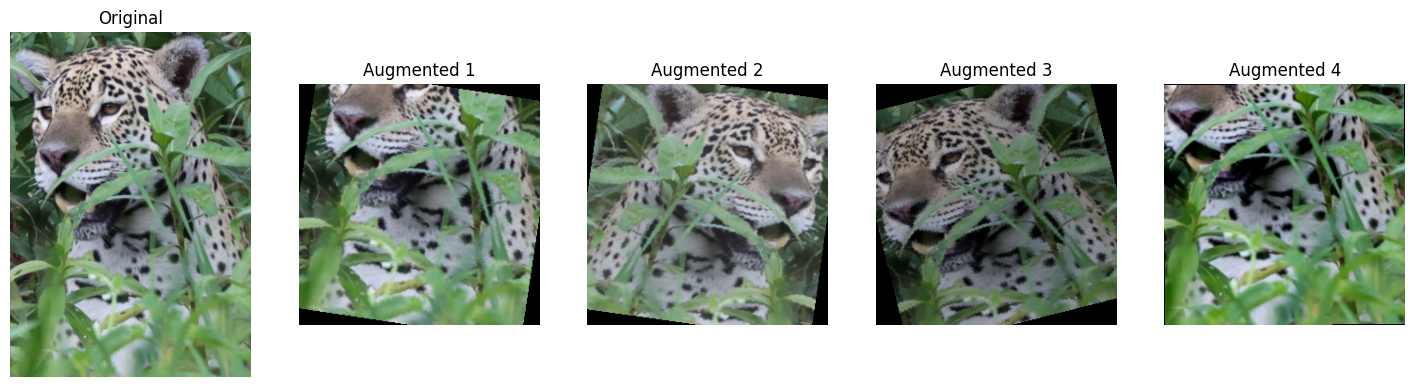

Example label map (first 10): {'Abril': 0, 'Akaloi': 1, 'Alira': 2, 'Apeiara': 3, 'Ariely': 4, 'Bagua': 5, 'Benita': 6, 'Bernard': 7, 'Guaraci': 8, 'Ipepo': 9}

Step 2 setup complete: transforms, splits, dataset and dataloaders are ready.
Next: implement training loop, loss (ArcFace/metric learning), and evaluation (identity-balanced mAP).


In [6]:
# Step 2: Data preprocessing, augmentations, group-aware split, and dataset skeleton

# Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Scikit-learn for group-aware splitting
from sklearn.model_selection import GroupShuffleSplit

# Paths
ROOT = Path('/Users/srikaruv/Desktop/Projects/Jaguar_Re-Identification')
DATA_DIR = ROOT / 'jaguar-re-id'
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV = DATA_DIR / 'test.csv'
TRAIN_IMG_DIR = DATA_DIR / 'train' / 'train'
TEST_IMG_DIR = DATA_DIR / 'test' / 'test'

# Load CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Identify columns
id_column = [c for c in train_df.columns if c.lower() in ['ground_truth', 'jaguar_id', 'identity', 'class']][0]
img_column = [c for c in train_df.columns if c.lower() in ['image', 'image_id', 'filename', 'image_path']][0]

print(f"Loaded train: {train_df.shape}, test: {test_df.shape}")
print(f"ID column: {id_column}, Image column: {img_column}")

# -----------------------------
# 1) Augmentations / Transforms
# -----------------------------
# Training transforms (PyTorch torchvision)
train_transform = T.Compose([
    T.RandomResizedCrop((256, 256), scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02)], p=0.6),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms
val_transform = T.Compose([
    T.Resize((288, 288)),
    T.CenterCrop((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Helper to unnormalize for visualization
def unnormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1,2,0)
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    return img

# ----------------------------------
# 2) Group-aware train/validation split
# ----------------------------------
# We'll split by jaguar identity so no identity appears in both train and val
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

groups = train_df[id_column].values
train_idx, val_idx = next(gss.split(train_df, groups=groups))

train_split_df = train_df.iloc[train_idx].reset_index(drop=True)
val_split_df = train_df.iloc[val_idx].reset_index(drop=True)

print(f"Train split: {train_split_df.shape}, Val split: {val_split_df.shape}")

# Save splits
split_dir = DATA_DIR / 'splits'
split_dir.mkdir(exist_ok=True)
train_split_df.to_csv(split_dir / 'train_split.csv', index=False)
val_split_df.to_csv(split_dir / 'val_split.csv', index=False)
print(f"Saved train/val splits to {split_dir}")

# -----------------------------
# 3) PyTorch Dataset skeleton
# -----------------------------
class JaguarDataset(Dataset):
    def __init__(self, df, img_dir, id_col, img_col, transform=None, label_map=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.id_col = id_col
        self.img_col = img_col
        self.transform = transform
        # Map string ids to integer labels if not provided
        if label_map is None:
            unique_ids = sorted(self.df[self.id_col].unique())
            self.label_map = {uid: i for i, uid in enumerate(unique_ids)}
        else:
            self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row[self.img_col]
        if not img_path.exists():
            # Try alternative: sometimes csv contains full paths
            img_path = Path(row[self.img_col])
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = self.label_map[row[self.id_col]]
        return img, label, row[self.img_col]

# Example instantiation
train_dataset = JaguarDataset(train_split_df, TRAIN_IMG_DIR, id_column, img_column, transform=train_transform)
val_dataset = JaguarDataset(val_split_df, TRAIN_IMG_DIR, id_column, img_column, transform=val_transform, label_map=train_dataset.label_map)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train dataset size: {len(train_dataset)}, Val dataset size: {len(val_dataset)}")

# -----------------------------
# 4) Visualize augmented samples
# -----------------------------
# Pick a random sample from train_split_df
sample_row = train_split_df.sample(1, random_state=42).iloc[0]
img_file = sample_row[img_column]
img_path = TRAIN_IMG_DIR / img_file

if img_path.exists():
    orig = Image.open(img_path).convert('RGB')
    fig, axes = plt.subplots(1, 5, figsize=(18, 6))
    axes[0].imshow(orig)
    axes[0].set_title('Original')
    axes[0].axis('off')
    for i in range(1,5):
        aug = train_transform(orig)
        axes[i].imshow(unnormalize(aug))
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')
    plt.show()
else:
    print(f"Sample image not found: {img_path}")

# -----------------------------
# 5) Quick sanity checks
# -----------------------------
# Check that label mapping is consistent
print('Example label map (first 10):', dict(list(train_dataset.label_map.items())[:10]))

print('\nStep 2 setup complete: transforms, splits, dataset and dataloaders are ready.')
print('Next: implement training loop, loss (ArcFace/metric learning), and evaluation (identity-balanced mAP).')
